<a href="https://colab.research.google.com/github/ajaykumar080286/DeepLearning/blob/master/16_feature_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout


In [19]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/MachineLearning/main/Social_Network_Ads.csv")

In [20]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [21]:
df.drop(columns=["User ID","Gender"],axis=1, inplace=True)

In [22]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [25]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

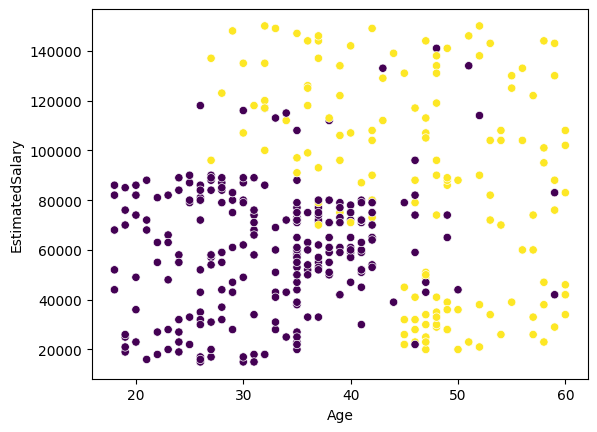

In [31]:
sns.scatterplot(x=X.iloc[:,0],y=X.iloc[:,1],c=y)

In [34]:
X_train, X_test, y_train, y_test =train_test_split(X,y, test_size=0.2, random_state=42)

In [36]:
model= Sequential()
model.add(Dense(128, activation="relu", input_dim=2))
model.add(Dense(1, activation="sigmoid"))

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(loss="binary_crossentropy", optimizer="Adam", metrics=["accuracy"])

In [41]:
history=model.fit(X_train, y_train, epochs=100, validation_data=(X_test,y_test))

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4969 - loss: 125.0343 - val_accuracy: 0.6500 - val_loss: 109.5256
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5531 - loss: 79.1176 - val_accuracy: 0.3500 - val_loss: 55.0976
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4594 - loss: 58.0260 - val_accuracy: 0.6500 - val_loss: 36.6056
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5406 - loss: 51.5817 - val_accuracy: 0.3500 - val_loss: 37.0148
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4875 - loss: 27.9604 - val_accuracy: 0.6500 - val_loss: 35.0809
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4781 - loss: 44.4636 - val_accuracy: 0.6500 - val_loss: 45.4711
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5531 - loss: 26.5275 - val_accuracy: 0.6375 - val_loss: 2.0471
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5312 - loss: 23.0923 - v

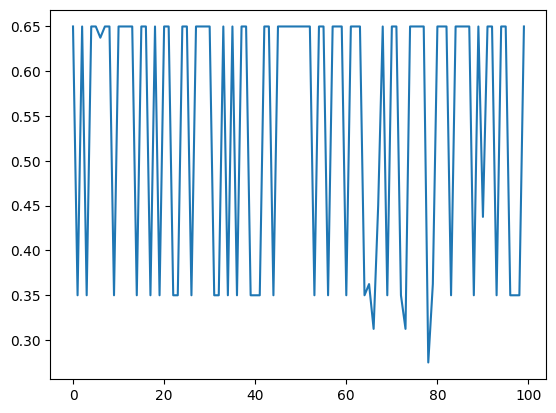

In [43]:
plt.plot(history.history["val_accuracy"])

In [44]:
from sklearn.preprocessing import StandardScaler

In [45]:
scale=StandardScaler()
X_train_scale=scale.fit_transform(X_train)
X_test_scale=scale.transform(X_test)

In [47]:
model= Sequential()
model.add(Dense(128, activation="relu", input_dim=2))
model.add(Dense(1, activation="sigmoid"))

In [48]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(loss="binary_crossentropy", optimizer="Adam", metrics=["accuracy"])

In [52]:
history=model.fit(X_train_scale, y_train, epochs=100, validation_data=(X_test_scale,y_test))

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6438 - loss: 0.6545 - val_accuracy: 0.6500 - val_loss: 0.5432
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7031 - loss: 0.5510 - val_accuracy: 0.8250 - val_loss: 0.4151
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7656 - loss: 0.4611 - val_accuracy: 0.8875 - val_loss: 0.3142
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8094 - loss: 0.3988 - val_accuracy: 0.9250 - val_loss: 0.2549
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8406 - loss: 0.3654 - val_accuracy: 0.9250 - val_loss: 0.2347
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8469 - loss: 0.3537 - val_accuracy: 0.9250 - val_loss: 0.2221
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8531 - loss: 0.3446 - val_accuracy: 0.9250 - val_loss: 0.2174
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8531 - loss: 0.3384 - val_accuracy: 0.

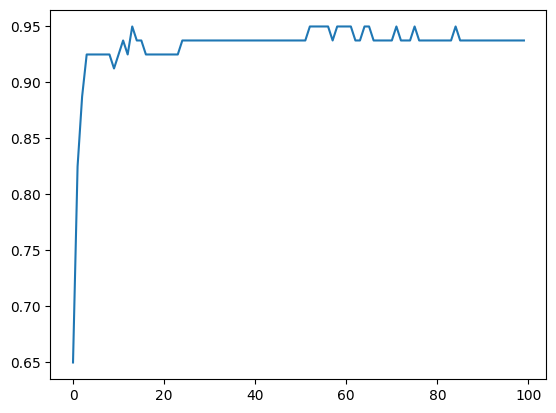

In [53]:
plt.plot(history.history["val_accuracy"])

<Axes: >

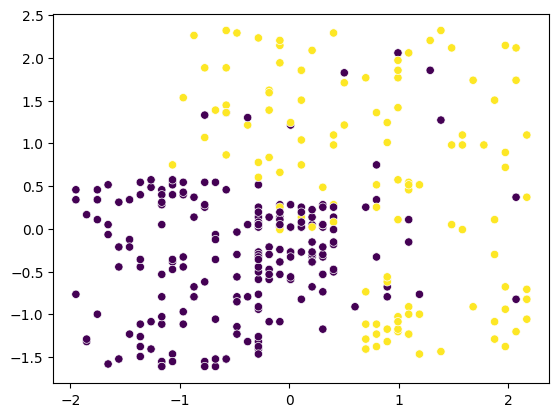

In [58]:
sns.scatterplot(x=X_train_scale[:,0],y=X_train_scale[:,1],c=y_train)